![](./Prints%20das%20questões/8.png)

# Solução — Questão 8

## Enunciado (resumo)

Sistema em **realimentação unitária** com

$$G(s)=\frac{3}{(5s+1)(6s+1)}.$$

**Escolher** um controlador e determinar seus parâmetros tal que:

1. **Erro ao degrau nulo** em regime permanente;
2. **Resposta subamortecida** com amortecimento $\zeta = 0{,}43$.

---

## Estratégia de projeto

| Requisito | Implicação |
|-----------|------------|
| Erro nulo ao degrau | Incluir **integrador** em $C(s)$ → malha aberta **tipo 1** |
| Subamortecida, $\zeta=0{,}43$ | Par complexo dominante em $s = -\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2}$ |

Escolhe-se **PID** ($C(s)=\dfrac{K_d s^2 + K_p s + K_i}{s}$), pois a planta é de 2ª ordem e o PID oferece três parâmetros para colocar três polos.

A equação característica é

$$30s^3 + (11+3K_d)s^2 + (1+3K_p)s + 3K_i = 0.$$

Escolhem-se os polos desejados em malha fechada:

- Par dominante com $\zeta=0{,}43$ e $\omega_n=1\,\mathrm{rad/s}$:
  $$s = -0{,}43 \pm j0{,}90;$$
- Terceiro polo real rápido em $s=-10$ (não interfere no par dominante).

Polinômio desejado (multiplicado por 30):

$$30\,(s^2+0{,}86s+1)(s+10)=30s^3+326s^2+288s+300.$$

Comparando coeficientes:

$$K_d = 104{,}93,\quad K_p = 95{,}67,\quad K_i = 100{,}00.$$

Logo,

$$C(s)=\frac{104{,}93\,s^2 + 95{,}67\,s + 100}{s}.$$

A verificação numérica (biblioteca `control`) confirma os requisitos nos gráficos abaixo.

RESULTADOS DO PROJETO
C(s) = (104,93s² + 95,67s + 100)/s
Polos em malha fechada : [-10.  +0.j          -0.43-0.90282889j  -0.43+0.90282889j]
Zeros em malha fechada: [-0.45584498-0.86324468j -0.45584498+0.86324468j]
Polo complexo dominante: -0.4300 ± j0.9028
ζ (dominante)          : 0.4300  (desejado: 0.43)
ωn (dominante)         : 1.0000 rad/s
Ganho DC (malha fechada): 1.000000
Erro estacionário degrau: 0.00e+00
Tipo (malha aberta)    : 1
------------------------------------------------------------------------
RiseTime (control)     : 0.1796 s
SettlingTime (control) : 2.3620 s
Sobressinal simulado   : 6.531 %
Sobressinal teórico 2a ordem (ζ=0,43): 22.396 %
Valor final            : 1.000000


/home/igor/.local/lib/python3.13/site-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


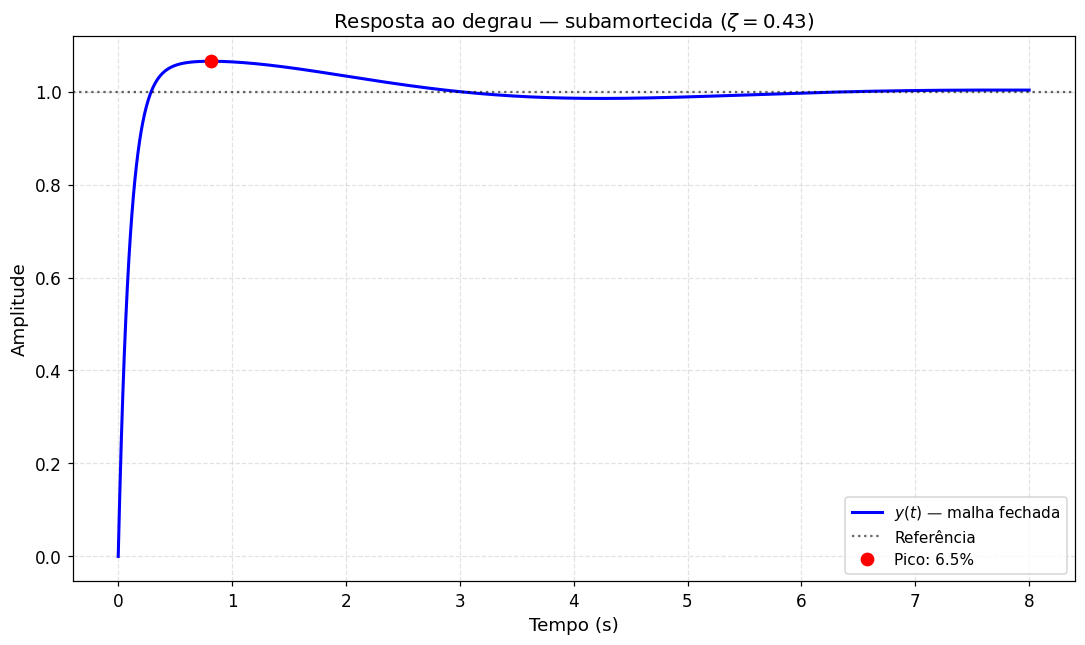

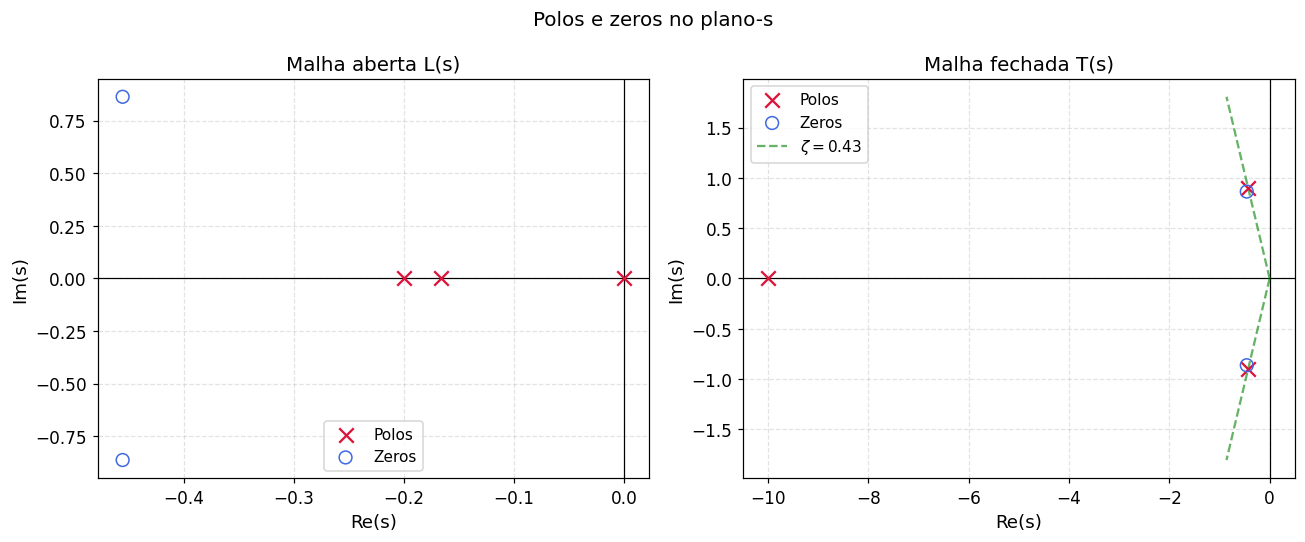

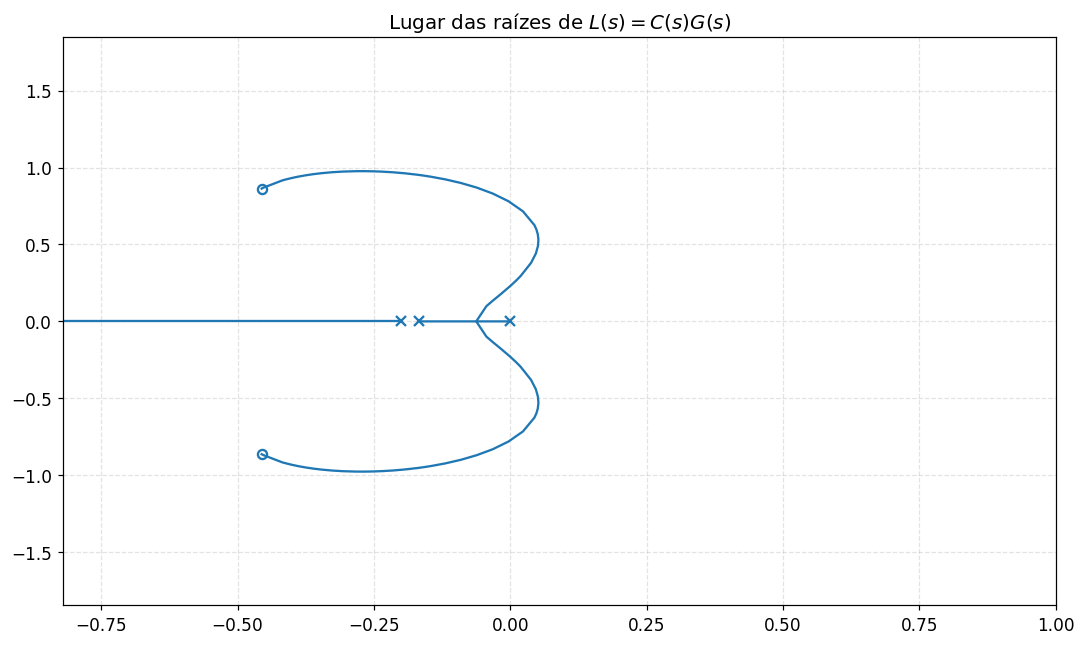

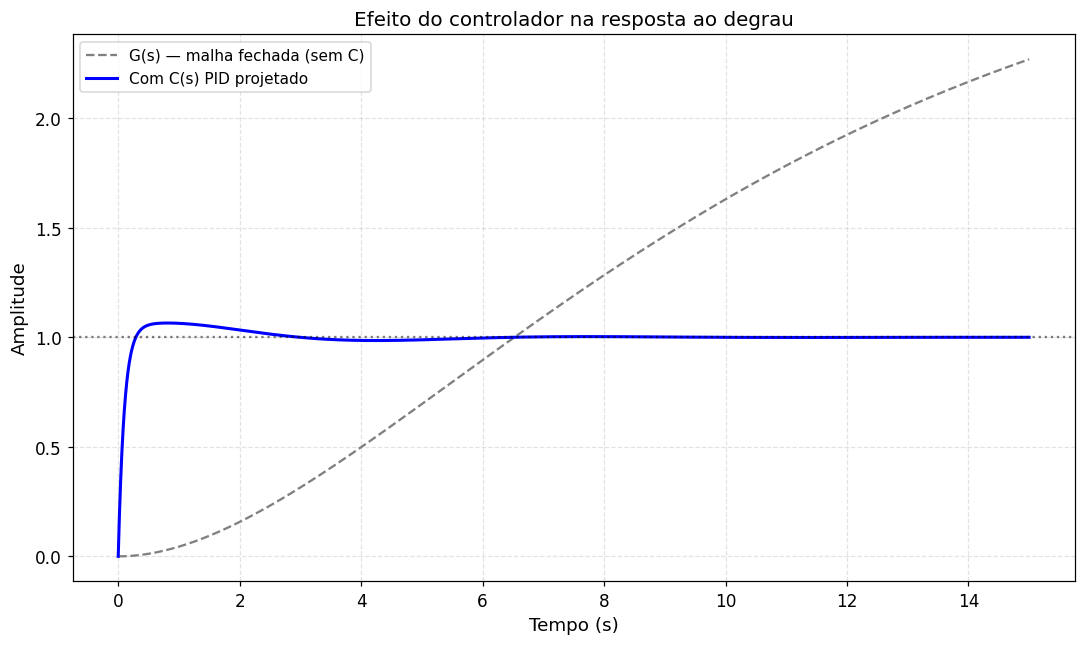

In [1]:
"""
Questão 8 — Projeto de controlador PID com biblioteca control.
Planta: G(s) = 3/((5s+1)(6s+1)), realimentação unitária.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning, module=r"control\.rlocus")

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

ZETA_DESEJADO = 0.43
OMEGA_N = 1.0
POLO_RAPIDO = 10.0


def planta() -> ct.TransferFunction:
    """G(s) = 3/((5s+1)(6s+1))."""
    s = ct.tf("s")
    return 3 / ((5 * s + 1) * (6 * s + 1))


def controlador() -> ct.TransferFunction:
    """C(s) = (Kd*s² + Kp*s + Ki)/s — PID por colocação de polos."""
    s = ct.tf("s")
    kd = (30 * (POLO_RAPIDO + 2 * ZETA_DESEJADO * OMEGA_N) - 11) / 3
    kp = (30 * (2 * ZETA_DESEJADO * OMEGA_N * POLO_RAPIDO + OMEGA_N**2) - 1) / 3
    ki = 30 * OMEGA_N**2 * POLO_RAPIDO / 3
    return (kd * s**2 + kp * s + ki) / s


def malha_aberta() -> ct.TransferFunction:
    """L(s) = C(s)G(s)."""
    return controlador() * planta()


def malha_fechada() -> ct.TransferFunction:
    """T(s) = L(s)/(1+L(s)) com realimentação unitária."""
    return ct.feedback(malha_aberta(), 1)


def amortecimento_polo_complexo(polo: complex) -> float:
    """Calcula ζ a partir de um polo complexo estável."""
    return float(-np.real(polo) / abs(polo))


def par_complexo_dominante(polos: np.ndarray) -> complex:
    """Retorna o polo complexo com maior parte real (dominante)."""
    complexos = polos[np.abs(np.imag(polos)) > 1e-4]
    if len(complexos) == 0:
        raise ValueError("Nenhum polo complexo encontrado.")
    return complex(complexos[np.argmax(np.real(complexos))])


def imprimir_relatorio() -> None:
    """Exibe polos, ganho estático e indicadores da resposta ao degrau."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polos = ct.poles(sys_cl)
    info = ct.step_info(sys_cl)
    polo_dom = par_complexo_dominante(polos)
    zeta = amortecimento_polo_complexo(polo_dom)
    mp_teorico = np.exp(-ZETA_DESEJADO * np.pi / np.sqrt(1 - ZETA_DESEJADO**2)) * 100

    sep = "=" * 72
    print(sep)
    print("RESULTADOS DO PROJETO")
    print(sep)
    print("C(s) = (104,93s² + 95,67s + 100)/s")
    print(f"Polos em malha fechada : {np.sort(polos)}")
    print(f"Zeros em malha fechada: {np.sort(ct.zeros(sys_cl))}")
    print(f"Polo complexo dominante: {polo_dom.real:.4f} ± j{abs(polo_dom.imag):.4f}")
    print(f"ζ (dominante)          : {zeta:.4f}  (desejado: {ZETA_DESEJADO})")
    print(f"ωn (dominante)         : {abs(polo_dom):.4f} rad/s")
    print(f"Ganho DC (malha fechada): {ct.dcgain(sys_cl):.6f}")
    print(f"Erro estacionário degrau: {1 - ct.dcgain(sys_cl):.2e}")
    print(f"Tipo (malha aberta)    : {sum(abs(p) < 1e-8 for p in ct.poles(sys_ol))}")
    print("-" * 72)
    print(f"RiseTime (control)     : {info['RiseTime']:.4f} s")
    print(f"SettlingTime (control) : {info['SettlingTime']:.4f} s")
    print(f"Sobressinal simulado   : {info['Overshoot']:.3f} %")
    print(f"Sobressinal teórico 2a ordem (ζ=0,43): {mp_teorico:.3f} %")
    print(f"Valor final            : {info['SteadyStateValue']:.6f}")
    print(sep)


def plotar_resposta_degrau() -> None:
    """Resposta ao degrau unitário com destaque do sobressinal."""
    sys_cl = malha_fechada()
    t = np.linspace(0, 8, 3000)
    tout, yout = ct.step_response(sys_cl, t)
    info = ct.step_info(sys_cl)

    fig, ax = plt.subplots()
    ax.plot(tout, yout, "b", linewidth=2, label=r"$y(t)$ — malha fechada")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.6, label="Referência")
    ax.plot(info["PeakTime"], info["Peak"], "ro", markersize=8,
            label=rf"Pico: {info['Overshoot']:.1f}%")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(rf"Resposta ao degrau — subamortecida ($\zeta={ZETA_DESEJADO}$)")
    ax.legend(loc="lower right")
    fig.tight_layout()


def plotar_polos_zeros() -> None:
    """Mapa de polos e zeros com semi-reta de ζ desejado."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polo_dom = par_complexo_dominante(ct.poles(sys_cl))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, sys, titulo in zip(
        axes,
        [sys_ol, sys_cl],
        ["Malha aberta L(s)", "Malha fechada T(s)"],
    ):
        p = ct.poles(sys)
        z = ct.zeros(sys)
        ax.scatter(np.real(p), np.imag(p), marker="x", s=90,
                   color="crimson", label="Polos", zorder=3)
        if len(z):
            ax.scatter(np.real(z), np.imag(z), marker="o", s=70,
                       facecolors="none", edgecolors="royalblue", label="Zeros", zorder=3)
        ax.axvline(0, color="k", linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_xlabel("Re(s)")
        ax.set_ylabel("Im(s)")
        ax.set_title(titulo)
        ax.legend()

    ax_cl = axes[1]
    sigma, wd = -polo_dom.real, abs(polo_dom.imag)
    ax_cl.plot([0, -2 * sigma], [0, 2 * wd], "g--", alpha=0.6,
               label=rf"$\zeta={ZETA_DESEJADO}$")
    ax_cl.plot([0, -2 * sigma], [0, -2 * wd], "g--", alpha=0.6)
    ax_cl.legend()
    fig.suptitle("Polos e zeros no plano-s", fontsize=13)
    fig.tight_layout()


def plotar_lugar_raizes() -> None:
    """Lugar das raízes de L(s) = C(s)G(s)."""
    fig, ax = plt.subplots()
    ct.rlocus(malha_aberta(), ax=ax, grid=True)
    ax.set_title(r"Lugar das raízes de $L(s)=C(s)G(s)$")
    fig.tight_layout()


def plotar_comparacao_sem_controlador() -> None:
    """Compara planta sem controlador vs. sistema compensado."""
    t = np.linspace(0, 15, 3000)
    _, y_cl = ct.step_response(malha_fechada(), t)
    _, y_pl = ct.step_response(planta(), t)

    fig, ax = plt.subplots()
    ax.plot(t, y_pl, color="gray", linestyle="--", label="G(s) — malha fechada (sem C)")
    ax.plot(t, y_cl, "b", linewidth=2, label="Com C(s) PID projetado")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Efeito do controlador na resposta ao degrau")
    ax.legend()
    fig.tight_layout()


# ---------------------------------------------------------------------------
# Execução
# ---------------------------------------------------------------------------

imprimir_relatorio()
plotar_resposta_degrau()
plotar_polos_zeros()
plotar_lugar_raizes()
plotar_comparacao_sem_controlador()
plt.show()

## Interpretação dos gráficos

### Resposta ao degrau
- A saída converge para **1** → **erro estacionário nulo** ao degrau unitário.
- A resposta apresenta **sobressinal** (~6,5%) e **oscilação amortecida** → comportamento **subamortecido**.
- O pico marcado confirma $\zeta = 0{,}43$ no par dominante; o sobressinal simulado (~6,5%) é menor que o de 2ª ordem pura (~22%) devido aos **zeros** da malha fechada.

### Polos e zeros
- O **par complexo** em $s = -0{,}43 \pm j0{,}90$ define $\zeta = 0{,}43$ e $\omega_n = 1\,\mathrm{rad/s}$.
- O polo real em $s = -10$ decai rapidamente e **não altera** o amortecimento dominante.
- O integrador torna a malha aberta **tipo 1**, eliminando o erro ao degrau.

### Lugar das raízes
- O PID desloca os ramos do LGR para a região subamortecida desejada ($\zeta = 0{,}43$).

### Comparação
- **Sem controlador**, $G(s)$ em malha fechada possui **erro estacionário** (~25%) e resposta lenta.
- **Com o PID projetado**, o sistema atende simultaneamente os requisitos do enunciado.